Installing

In [1]:
import sys, pathlib
print(sys.executable)                   # should end in IU_Proj\.venv\Scripts\python.exe

ROOT = pathlib.Path.cwd().parent        # Notebooks/ -> IU_Proj/
sys.path.insert(0, str(ROOT))
print(ROOT)                             # should be C:\Users\ronak\IU_Proj

C:\Users\ronak\IU_Proj\.venv\Scripts\python.exe
C:\Users\ronak\IU_Proj


In [2]:
import sys; print(sys.executable)


C:\Users\ronak\IU_Proj\.venv\Scripts\python.exe


In [3]:
# Downloads PneumoniaMNIST from the official MedMNIST Zenodo record (skipped if already present)
from src.download_data import download

dest = download()
print(dest, dest.stat().st_size / 1e6, "MB")

C:\Users\ronak\IU_Proj\data\pneumoniamnist.npz 4.170669 MB


In [4]:
import numpy as np
npz = np.load(ROOT / "data" / "pneumoniamnist.npz", allow_pickle=False)
print(npz.files)

['train_images', 'val_images', 'test_images', 'train_labels', 'val_labels', 'test_labels']


Part 1 :

Ingest and structure

In [5]:
# Build the per-image metadata table and store it in DuckDB
import duckdb
from src.build_metadata import build_metadata, write_duckdb, DB_PATH, TABLE

meta = build_metadata(dest)
write_duckdb(meta)

# Short-lived connection so re-running this cell can rewrite the file
with duckdb.connect(str(DB_PATH), read_only=True) as con:
    summary = con.sql(f"SELECT split, label_name, count(*) AS n FROM {TABLE} GROUP BY ALL ORDER BY 1, 2").df()
summary

with duckdb.connect(str(DB_PATH), read_only=True) as con:
    required = con.sql(f"""
        SELECT image_id, split, label, width, height,
               mean_intensity, std_intensity, min_intensity, max_intensity
        FROM {TABLE}
        ORDER BY split, split_index
    """).df()
print(len(required), "rows")
required.head(10)

5856 rows


,image_id,split,label,width,height,mean_intensity,std_intensity,min_intensity,max_intensity
0,test_00000,test,1,28,28,134.868622,41.383218,12,197
1,test_00001,test,0,28,28,153.191327,33.389501,73,212
2,test_00002,test,1,28,28,153.554847,43.863797,41,225
3,test_00003,test,0,28,28,140.718112,52.479767,0,231
4,test_00004,test,1,28,28,151.146684,30.564672,40,193
5,test_00005,test,1,28,28,153.466837,25.298250,84,194
6,test_00006,test,1,28,28,157.903061,24.392586,63,199
7,test_00007,test,1,28,28,171.035714,14.944924,123,196
8,test_00008,test,1,28,28,140.534439,30.324795,57,201
9,test_00009,test,0,28,28,142.693878,40.018403,39,218


Validation

In [6]:
# Data-quality checks: split counts, labels, dimensions, missing/invalid values,
# low pixel variance, exact duplicates (SHA-1 of pixels). Results are saved to DuckDB.
import pandas as pd
from src.validate import run_checks, write_results

results, low_var, dups = run_checks(meta, dest)
write_results(results, low_var, dups)
pd.set_option("display.max_colwidth", None)
results

,check,status,detail
0,split_counts,PASS,"train=4708 (expected 4708), val=524 (expected 524), test=624 (expected 624)"
1,label_values,PASS,"0 rows with labels outside [0, 1]; observed [0, 1]"
2,image_dimensions,PASS,"all images 28x28, 1 channel"
3,missing_or_invalid,PASS,"no nulls, non-finite, out-of-range or inconsistent values"
4,low_variance,WARN,46 images with std_intensity < 14.21 (Q1 - 1.5 x IQR); lowest std 6.32
5,exact_duplicates,WARN,27 groups of identical images covering 56 images (SHA-1 of pixels); 8 groups span splits; 0 groups have conflicting labels


In [7]:
# Flagged images: lowest-variance images and groups of identical images
display(low_var.head(10))
dups

,image_id,split,label,mean_intensity,std_intensity,threshold
3951,train_03327,train,1,193.464286,6.315978,14.208792
5526,val_00194,val,1,195.747449,7.735585,14.208792
3563,train_02939,train,1,193.098214,8.321156,14.208792
831,train_00207,train,1,175.352041,8.741529,14.208792
2120,train_01496,train,1,175.659439,9.093342,14.208792
5243,train_04619,train,1,195.084184,9.323990,14.208792
4843,train_04219,train,1,170.369898,9.832833,14.208792
3573,train_02949,train,1,192.225765,9.868978,14.208792
2137,train_01513,train,1,161.922194,10.235882,14.208792
4102,train_03478,train,1,170.021684,10.320541,14.208792


,pixel_sha1,n_images,image_ids,splits,n_labels
10,50b2cc3ae37eabb2c49dd5d8bc13a1591dfcfa4d,3,"train_00289,train_03170,val_00172","train,val",1
16,596ac53fc09cf5a5d00439973524b13e3c7b8f34,3,"train_01440,train_03874,val_00253","train,val",1
15,579fd0fa22c8b92e5ada9b73fb3ae4444886f097,2,"test_00170,test_00311",test,1
24,f1981cce49da0bf77e179c61c8f31672b9914bf3,2,"test_00302,test_00401",test,1
14,559fbb4b78726a0665214c26864f82e2f11245bd,2,"test_00440,test_00538",test,1
21,b53c422e1d3ddf69890bb8b200d9c6cdd1e8fa23,2,"train_00029,train_03365",train,1
12,55416f419ab6faa35bd0c1f38326cdf9fed7a0ed,2,"train_00097,train_04422",train,1
11,51c0843cc60e5615ce9755367617eaa56c3e7939,2,"train_00226,train_01366",train,1
18,61b5faf562888ccb4fe6ae5e15c5da5ffc48cc43,2,"train_00662,val_00236","train,val",1
17,606ee40de8624369a9d1a0499d2b1ba75ba6a39a,2,"train_00779,train_03781",train,1


In [8]:
# Do exact duplicates occur across train/val/test splits?
with duckdb.connect(str(DB_PATH), read_only=True) as con:
    display(con.sql("""
        SELECT splits, count(*) AS n_groups, sum(n_images) AS n_images
        FROM duplicate_images GROUP BY splits ORDER BY splits
    """).df())
    cross_split = con.sql("""
        SELECT image_ids, splits, n_labels
        FROM duplicate_images WHERE splits LIKE '%,%' ORDER BY image_ids
    """).df()

# Double-check the hash matches pixel by pixel
for ids in cross_split["image_ids"]:
    imgs = [npz[f"{i.rsplit('_', 1)[0]}_images"][int(i.rsplit('_', 1)[1])] for i in ids.split(",")]
    assert all(np.array_equal(imgs[0], im) for im in imgs[1:]), ids

print(f"{len(cross_split)} duplicate groups span splits (pixel-identical, "
      f"{(cross_split['n_labels'] > 1).sum()} with conflicting labels)")
cross_split

,splits,n_groups,n_images
0,test,3,6.0
1,train,16,32.0
2,"train,val",8,18.0


8 duplicate groups span splits (pixel-identical, 0 with conflicting labels)


,image_ids,splits,n_labels
0,"train_00289,train_03170,val_00172","train,val",1
1,"train_00662,val_00236","train,val",1
2,"train_01440,train_03874,val_00253","train,val",1
3,"train_01834,val_00473","train,val",1
4,"train_02041,val_00061","train,val",1
5,"train_03130,val_00302","train,val",1
6,"train_04036,val_00244","train,val",1
7,"train_04193,val_00105","train,val",1


Part 2: SQL and Data Analysis

Part A:

In [9]:
# Class balance per split: total, normal, pneumonia, % pneumonia (query in sql/split_summary.sql)
split_summary_sql = (ROOT / "sql" / "split_summary.sql").read_text()
print(split_summary_sql)

with duckdb.connect(str(DB_PATH), read_only=True) as con:
    split_summary = con.sql(split_summary_sql).df()
split_summary

-- Class balance per split (label 0 = normal, 1 = pneumonia), plus an overall row.
-- Run against output/pneumoniamnist.duckdb, e.g.:
--   duckdb output/pneumoniamnist.duckdb < sql/split_summary.sql
SELECT
    COALESCE(split, 'all')                                  AS split,
    COUNT(*)                                                AS total_images,
    COUNT(*) FILTER (WHERE label = 0)                       AS normal_images,
    COUNT(*) FILTER (WHERE label = 1)                       AS pneumonia_images,
    ROUND(100.0 * COUNT(*) FILTER (WHERE label = 1) / COUNT(*), 2) AS pct_pneumonia
FROM image_metadata
GROUP BY ROLLUP (split)
ORDER BY
    CASE split WHEN 'train' THEN 1 WHEN 'val' THEN 2 WHEN 'test' THEN 3 ELSE 4 END;



,split,total_images,normal_images,pneumonia_images,pct_pneumonia
0,train,4708,1214,3494,74.21
1,val,524,135,389,74.24
2,test,624,234,390,62.50
3,all,5856,1583,4273,72.97


Part B:


In [10]:
# Normal vs pneumonia: distribution of each per-image statistic (query in sql/intensity_by_class.sql)
with duckdb.connect(str(DB_PATH), read_only=True) as con:
    by_class = con.sql((ROOT / "sql" / "intensity_by_class.sql").read_text()).df()
by_class

,statistic,class,n_images,mean,sd,q1,median,q3
0,mean_intensity,normal,1583,140.20,14.36,130.94,140.93,149.57
1,mean_intensity,pneumonia,4273,147.55,21.13,135.11,149.79,162.32
2,std_intensity,normal,1583,44.12,8.11,38.53,43.08,49.13
3,std_intensity,pneumonia,4273,34.41,8.02,29.41,34.25,39.37
4,median_intensity,normal,1583,145.44,15.73,136.00,146.00,155.00
5,median_intensity,pneumonia,4273,153.32,24.01,140.00,156.00,170.50
6,min_intensity,normal,1583,21.43,24.31,0.00,11.00,40.00
7,min_intensity,pneumonia,4273,47.90,29.41,27.00,48.00,66.00
8,max_intensity,normal,1583,223.98,14.05,216.00,226.00,233.00
9,max_intensity,pneumonia,4273,202.37,17.79,193.00,201.00,214.00


In [11]:
# Size of the difference (pneumonia - normal) and whether it holds in every split
# (query in sql/intensity_effect_size.sql; Cohen's d: ~0.2 small, ~0.5 medium, ~0.8 large)
with duckdb.connect(str(DB_PATH), read_only=True) as con:
    effect_size = con.sql((ROOT / "sql" / "intensity_effect_size.sql").read_text()).df()
effect_size

,statistic,split,normal_mean,pneumonia_mean,diff,cohens_d
0,mean_intensity,train,139.90,147.90,8.00,0.41
1,mean_intensity,val,140.49,146.75,6.26,0.32
2,mean_intensity,test,141.59,145.15,3.56,0.20
3,mean_intensity,all,140.20,147.55,7.35,0.38
4,std_intensity,train,44.03,34.42,-9.61,-1.19
5,std_intensity,val,44.40,34.39,-10.01,-1.21
6,std_intensity,test,44.44,34.35,-10.10,-1.33
7,std_intensity,all,44.12,34.41,-9.71,-1.21


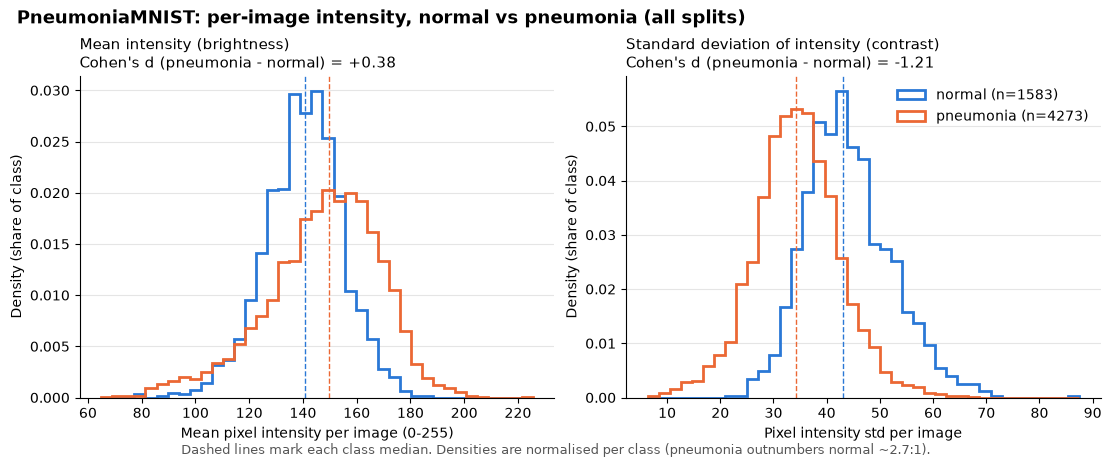

In [12]:
# Distribution of per-image mean and std intensity, normal vs pneumonia
import matplotlib.pyplot as plt

with duckdb.connect(str(DB_PATH), read_only=True) as con:
    stats = con.sql(f"SELECT label_name, mean_intensity, std_intensity FROM {TABLE}").df()

CLASS_COLORS = {"normal": "#2a78d6", "pneumonia": "#eb6834"}
panels = [("mean_intensity", "Mean intensity (brightness)", "Mean pixel intensity per image (0-255)"),
          ("std_intensity", "Standard deviation of intensity (contrast)", "Pixel intensity std per image")]
d_all = effect_size[effect_size["split"] == "all"].set_index("statistic")["cohens_d"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)
for ax, (col, title, xlabel) in zip(axes, panels):
    bins = np.linspace(stats[col].min(), stats[col].max(), 40)
    for cls, color in CLASS_COLORS.items():
        vals = stats.loc[stats["label_name"] == cls, col]
        ax.hist(vals, bins=bins, density=True, histtype="step", linewidth=2, color=color,
                label=f"{cls} (n={len(vals)})")
        ax.axvline(vals.median(), color=color, linestyle="--", linewidth=1)
    ax.set_title(f"{title}\nCohen's d (pneumonia - normal) = {d_all[col]:+.2f}", loc="left", fontsize=11)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density (share of class)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e5e5e5", linewidth=0.8)
    ax.set_axisbelow(True)
axes[1].legend(frameon=False)
fig.suptitle("PneumoniaMNIST: per-image intensity, normal vs pneumonia (all splits)",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.text(0.5, -0.02, "Dashed lines mark each class median. Densities are normalised per class "
         "(pneumonia outnumbers normal ~2.7:1).", ha="center", fontsize=9, color="#555")
fig.savefig(ROOT / "output" / "intensity_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

Part c:

**How unusual images were selected.** For each image's mean intensity (brightness) and standard deviation of intensity (contrast), we compute a *robust z-score* across all 5,856 images:

$$z = \frac{x - \text{median}(x)}{1.4826 \times \text{MAD}(x)}, \qquad \text{MAD} = \text{median}(|x - \text{median}(x)|)$$

The median and MAD are used instead of the mean and SD because they are not pulled towards the outliers we are trying to find; the factor 1.4826 puts MAD on the same scale as an SD. An image is flagged when $|z| > 3.5$, the standard outlier cutoff of Iglewicz & Hoaglin (1993):

- **very dark / very bright:** mean-intensity z < −3.5 / > +3.5
- **very low / very high contrast:** std-intensity z < −3.5 / > +3.5

The selection is done in SQL (`sql/unusual_images.sql`). The grid below shows the up to 4 most extreme images per reason (skipping exact duplicates), next to 4 typical images (closest to the median) for comparison. All images use the same fixed 0–255 grey scale. These are unusual *as images*; this says nothing about whether they are medically abnormal.

In [13]:
# Flag unusual images by robust z-score (query in sql/unusual_images.sql)
with duckdb.connect(str(DB_PATH), read_only=True) as con:
    unusual = con.sql((ROOT / "sql" / "unusual_images.sql").read_text()).df()

print(f"{unusual['image_id'].nunique()} unusual images out of {len(meta)} "
      f"({unusual['image_id'].nunique() / len(meta):.1%})")
display(unusual.groupby(["reason", "label_name"]).size().unstack(fill_value=0))
unusual.drop(columns="pixel_sha1")

32 unusual images out of 5856 (0.5%)


label_name,normal,pneumonia
reason,,
very bright,0,1
very dark,1,9
very high contrast,18,3
very low contrast,0,1


,reason,image_id,split,split_index,label_name,mean_intensity,std_intensity,min_intensity,max_intensity,robust_z,rank_in_reason
0,very bright,train_02377,train,2377,pneumonia,225.5,12.9,185,249,4.15,1
1,very dark,test_00151,test,151,pneumonia,64.9,22.5,17,140,-4.30,1
2,very dark,train_00821,train,821,pneumonia,70.6,23.0,17,143,-4.01,2
3,very dark,train_01690,train,1690,pneumonia,72.1,19.2,27,130,-3.93,3
4,very dark,train_04590,train,4590,pneumonia,72.1,19.2,27,130,-3.93,4
5,very dark,train_04426,train,4426,pneumonia,73.4,51.0,4,197,-3.86,5
6,very dark,train_02528,train,2528,pneumonia,76.9,29.0,2,152,-3.68,6
7,very dark,train_03911,train,3911,pneumonia,77.4,22.6,35,133,-3.65,7
8,very dark,test_00165,test,165,normal,78.4,87.4,0,235,-3.60,8
9,very dark,train_01435,train,1435,pneumonia,78.7,24.8,13,136,-3.58,9


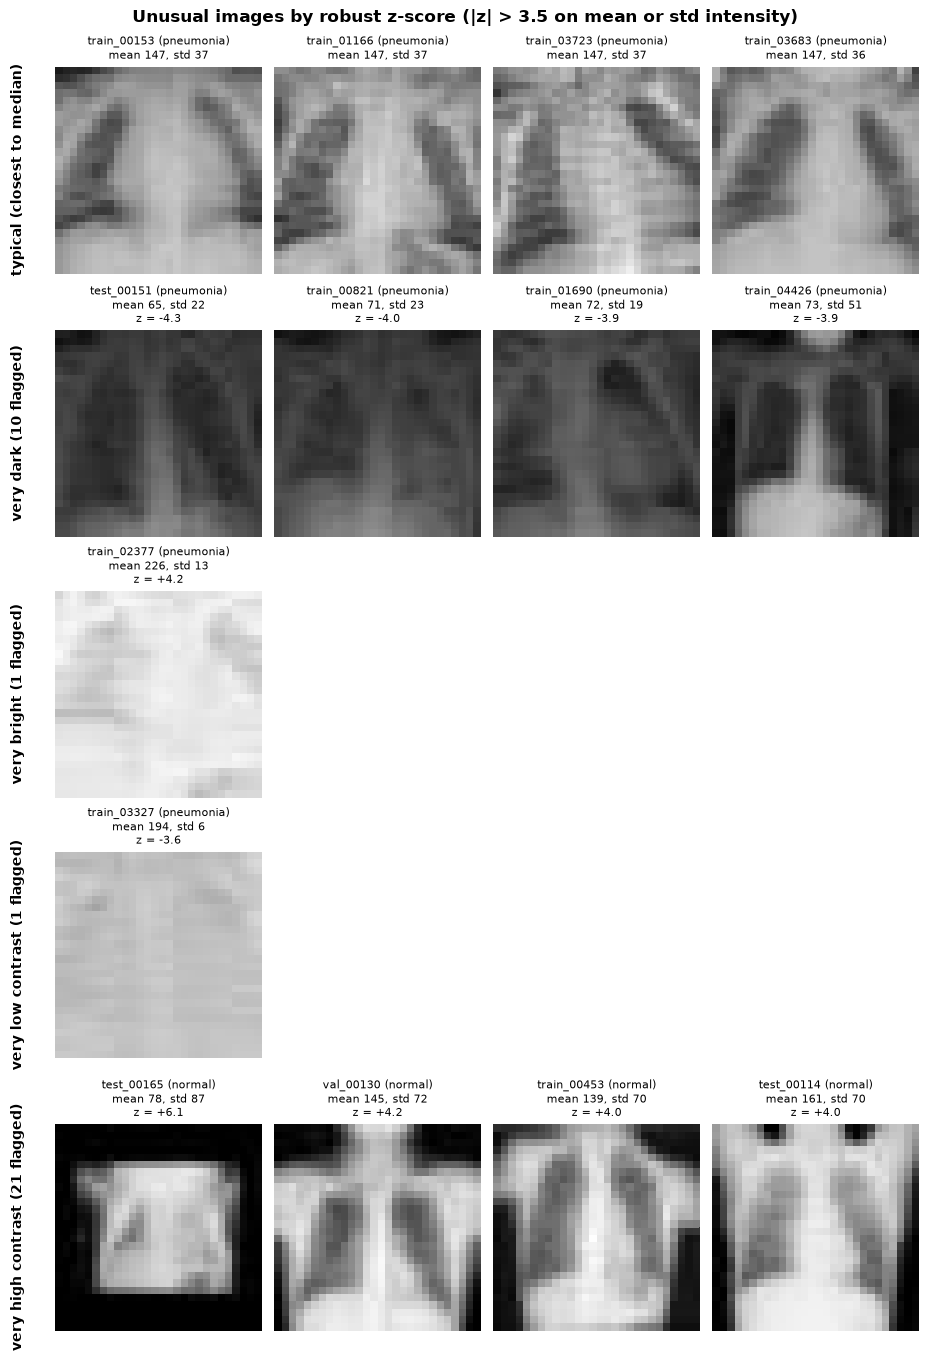

In [14]:
# Show the most extreme flagged images per reason, next to typical images for reference.
# All images use the same fixed 0-255 grey scale, so brightness/contrast are comparable.
N_PER_ROW = 4

def get_image(split, idx):
    return npz[f"{split}_images"][idx]

# Most extreme per reason, skipping exact duplicates of an image already shown
shown_hashes, rows = set(), {}
for reason in ["very dark", "very bright", "very low contrast", "very high contrast"]:
    grp = unusual[unusual["reason"] == reason]
    if grp.empty:
        continue
    picks = []
    for r in grp.sort_values("rank_in_reason").itertuples():
        if r.pixel_sha1 not in shown_hashes:
            picks.append(r); shown_hashes.add(r.pixel_sha1)
        if len(picks) == N_PER_ROW:
            break
    rows[f"{reason} ({len(grp)} flagged)"] = picks

# Reference row: images closest to the median on both mean and std
with duckdb.connect(str(DB_PATH), read_only=True) as con:
    typical = con.sql(f"""
        SELECT image_id, split, split_index, label_name,
               ROUND(mean_intensity, 1) AS mean_intensity, ROUND(std_intensity, 1) AS std_intensity
        FROM {TABLE}
        ORDER BY ABS(mean_intensity - (SELECT MEDIAN(mean_intensity) FROM {TABLE}))
               + ABS(std_intensity  - (SELECT MEDIAN(std_intensity)  FROM {TABLE}))
        LIMIT {N_PER_ROW}
    """).df()
rows = {"typical (closest to median)": list(typical.itertuples()), **rows}

fig, axes = plt.subplots(len(rows), N_PER_ROW, figsize=(2.3 * N_PER_ROW, 2.7 * len(rows)),
                         constrained_layout=True)
for axrow, (row_title, picks) in zip(axes, rows.items()):
    for j, ax in enumerate(axrow):
        ax.axis("off")
        if j < len(picks):
            r = picks[j]
            ax.imshow(get_image(r.split, r.split_index), cmap="gray", vmin=0, vmax=255,
                      interpolation="nearest")
            z = f"\nz = {r.robust_z:+.1f}" if hasattr(r, "robust_z") else ""
            ax.set_title(f"{r.image_id} ({r.label_name})\nmean {r.mean_intensity:.0f}, std {r.std_intensity:.0f}{z}",
                         fontsize=8)
    axrow[0].text(-0.15, 0.5, row_title, transform=axrow[0].transAxes, rotation=90,
                  ha="right", va="center", fontsize=10, fontweight="bold")
fig.suptitle("Unusual images by robust z-score (|z| > 3.5 on mean or std intensity)",
             fontsize=12, fontweight="bold")
fig.savefig(ROOT / "output" / "unusual_images.png", dpi=150, bbox_inches="tight")
plt.show()

Part 3: Simple CPU Baseline

**Model and evaluation protocol.** Logistic regression on the 784 flattened pixels (scaled to [0, 1], then standardised), with `class_weight="balanced"` because pneumonia outnumbers normal ~3:1 in train. Code: `src/baseline.py`.

| Split | Used for |
|---|---|
| **train** (4,708) | fitting the model |
| **val** (516 of 524) | choosing C from {0.001, 0.01, 0.1, 1} by ROC AUC, then the decision threshold by Youden's J (max sensitivity + specificity − 1). The 8 val images that are exact duplicates of train images are excluded, so selection isn't done on images the model has already seen. |
| **test** (624) | final evaluation, run once with the chosen C and threshold. No test image duplicates a train or val image. |

No other tuning was done.

In [15]:
# Fit on train; choose C and threshold on validation (train-duplicates excluded)
from sklearn.metrics import roc_auc_score
from src.baseline import load_splits, select_model, evaluate, not_in

data = load_splits(dest)
model, selection, search = select_model(data)

X_val, y_val, img_val = data["val"]
keep = not_in(img_val, data["train"][2])
X_val, y_val = X_val[keep], y_val[keep]
p_val = model.predict_proba(X_val)[:, 1]

display(pd.DataFrame(search).rename(columns={"val_auc": "val ROC AUC"}))
print(f"Chosen: C = {selection['C']}, threshold = {selection['threshold']:.3f} "
      f"(val sensitivity {selection['val_sensitivity']:.3f}, specificity {selection['val_specificity']:.3f}; "
      f"{selection['n_val_used']} val images, {selection['n_val_dropped_dup']} train-duplicates dropped)")

,C,val ROC AUC
0,0.001,0.988665
1,0.010,0.991679
2,0.100,0.990610
3,1.000,0.986566


Chosen: C = 0.01, threshold = 0.588 (val sensitivity 0.937, specificity 0.985; 516 val images, 8 train-duplicates dropped)


In [16]:
# Final evaluation on test (run once, with the C and threshold chosen on validation).
# The "always pneumonia" row is a reference point: it shows what accuracy alone rewards.
X_test, y_test, img_test = data["test"]
p_test = model.predict_proba(X_test)[:, 1]
test_result = evaluate(y_test, p_test, selection["threshold"])

metrics = pd.DataFrame({
    "logistic regression (test)": test_result,
    "always predict pneumonia (test)": evaluate(y_test, np.ones(len(y_test)), 0.5),
    "logistic regression (val, for comparison)": evaluate(y_val, p_val, selection["threshold"]),
}).T[["n", "accuracy", "sensitivity", "specificity", "balanced_accuracy", "roc_auc", "tn", "fp", "fn", "tp"]]
display(metrics.astype({c: int for c in ["n", "tn", "fp", "fn", "tp"]}).round(3))

print("Test confusion matrix (rows = actual, columns = predicted):")
pd.DataFrame([[test_result["tn"], test_result["fp"]], [test_result["fn"], test_result["tp"]]],
             index=["actual normal", "actual pneumonia"], columns=["pred normal", "pred pneumonia"])

,n,accuracy,sensitivity,specificity,balanced_accuracy,roc_auc,tn,fp,fn,tp
logistic regression (test),624,0.885,0.964,0.752,0.858,0.930,176,58,14,376
always predict pneumonia (test),624,0.625,1.000,0.000,0.500,0.500,0,234,0,390
"logistic regression (val, for comparison)",516,0.950,0.937,0.985,0.961,0.992,133,2,24,357


Test confusion matrix (rows = actual, columns = predicted):


,pred normal,pred pneumonia
actual normal,176,58
actual pneumonia,14,376


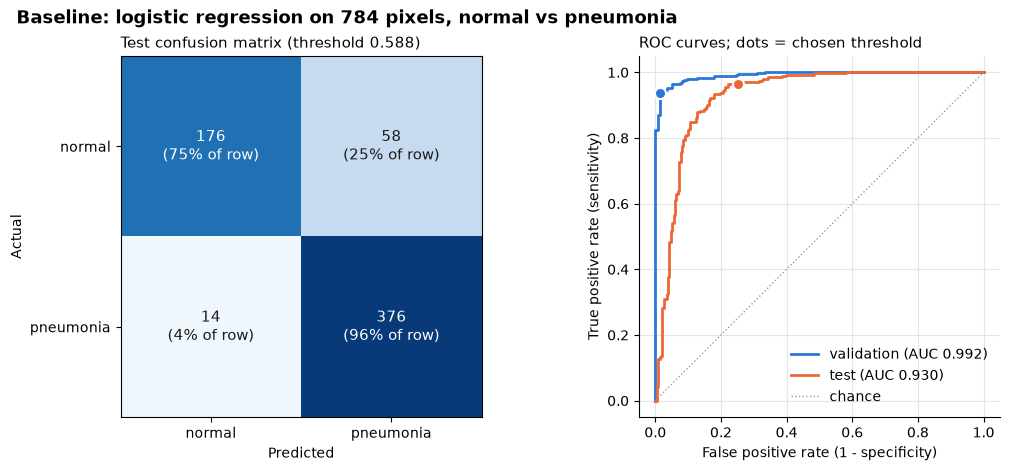

In [17]:
# Figure: test confusion matrix + ROC curves (val vs test) with the chosen operating point
from sklearn.metrics import roc_curve

fig, (ax_cm, ax_roc) = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True,
                                    gridspec_kw={"width_ratios": [1, 1.25]})

# Confusion matrix (counts + row %), single-hue scale
cm = np.array([[test_result["tn"], test_result["fp"]], [test_result["fn"], test_result["tp"]]])
row_pct = cm / cm.sum(axis=1, keepdims=True)
ax_cm.imshow(row_pct, cmap="Blues", vmin=0, vmax=1)
for i in range(2):
    for j in range(2):
        ax_cm.text(j, i, f"{cm[i, j]}\n({row_pct[i, j]:.0%} of row)", ha="center", va="center",
                   fontsize=11, color="white" if row_pct[i, j] > 0.5 else "#1a1a1a")
ax_cm.set_xticks([0, 1], ["normal", "pneumonia"])
ax_cm.set_yticks([0, 1], ["normal", "pneumonia"])
ax_cm.set_xlabel("Predicted")
ax_cm.set_ylabel("Actual")
ax_cm.set_title(f"Test confusion matrix (threshold {selection['threshold']:.3f})", loc="left", fontsize=11)

# ROC curves: validation (used for selection) vs test (final)
for name, (y_true, prob), color in [("validation", (y_val, p_val), "#2a78d6"),
                                    ("test", (y_test, p_test), "#eb6834")]:
    fpr, tpr, thr = roc_curve(y_true, prob)
    auc = roc_auc_score(y_true, prob)
    ax_roc.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC {auc:.3f})")
    k = np.argmin(np.abs(thr - selection["threshold"]))
    ax_roc.plot(fpr[k], tpr[k], "o", markersize=8, color=color, markeredgecolor="white", markeredgewidth=1.5)
ax_roc.plot([0, 1], [0, 1], color="#999", linestyle=":", linewidth=1, label="chance")
ax_roc.set_xlabel("False positive rate (1 - specificity)")
ax_roc.set_ylabel("True positive rate (sensitivity)")
ax_roc.set_title("ROC curves; dots = chosen threshold", loc="left", fontsize=11)
ax_roc.legend(frameon=False, loc="lower right")
ax_roc.spines[["top", "right"]].set_visible(False)
ax_roc.grid(color="#e5e5e5", linewidth=0.8)
ax_roc.set_aspect("equal")

fig.suptitle("Baseline: logistic regression on 784 pixels, normal vs pneumonia",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.savefig(ROOT / "output" / "baseline_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

**Results (test set, evaluated once).** Accuracy 0.885, sensitivity (pneumonia recall) 0.964, specificity 0.752, balanced accuracy 0.858, ROC AUC 0.930. Of 234 normal images, 58 (25%) were wrongly flagged as pneumonia; of 390 pneumonia images, 14 (4%) were missed.

**Why accuracy alone is misleading.** The classes are imbalanced: 62.5% of test images (and 74% of train/val) are pneumonia. A "model" that always answers *pneumonia* scores 62.5% test accuracy while having 0% specificity — it never identifies a single normal image. Accuracy mixes the two error types in proportion to class frequency, so it hides *which* class is failing: our 88.5% accuracy looks good, but it hides that a quarter of normal patients are false alarms. It also changes with prevalence: the same model would score differently on a population with a different pneumonia rate, even though its sensitivity and specificity would not change. Sensitivity, specificity (or balanced accuracy) and the confusion matrix show each error type separately; ROC AUC summarises performance across all thresholds.

**Validation vs test gap.** Test performance is clearly lower than validation (AUC 0.930 vs 0.992; specificity 0.752 vs 0.985), and the threshold chosen on validation lands at a different operating point on test (see the dots on the ROC plot). Validation was drawn from the same pool as train, while test differs: it has a different class balance (62.5% vs 74% pneumonia) and a smaller brightness difference between classes (Part 2). The validation numbers are therefore optimistic, and the test numbers are the honest estimate. We report this gap rather than tuning on test to close it.

Part 4: Research/Data Engineering Judgment

The written answers (data leakage, scaling, incremental processing, validation) are in `README.md`. The cell below is the evidence behind question 4: how much of the model's performance can be reached from global image statistics alone, using the same train/val/test protocol.

In [18]:
# Shortcut check: how far do 5 global intensity statistics get, vs all 784 pixels?
# Same protocol: fit on train, report val and test ROC AUC (threshold-free).
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

STAT_COLS = ["mean_intensity", "std_intensity", "min_intensity", "max_intensity", "median_intensity"]
by_split = {s: meta[meta["split"] == s].sort_values("split_index") for s in ("train", "val", "test")}
val_rows = by_split["val"][keep]  # same val subset as the pixel model (train-duplicates dropped)

rows = []
for name, cols in [("std_intensity only", ["std_intensity"]), ("5 global statistics", STAT_COLS)]:
    clf = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced"))
    clf.fit(by_split["train"][cols], by_split["train"]["label"])
    rows.append({"features": name,
                 "val_auc": roc_auc_score(val_rows["label"], clf.predict_proba(val_rows[cols])[:, 1]),
                 "test_auc": roc_auc_score(by_split["test"]["label"], clf.predict_proba(by_split["test"][cols])[:, 1])})
rows.append({"features": "784 pixels (baseline)",
             "val_auc": roc_auc_score(y_val, p_val), "test_auc": test_result["roc_auc"]})
pd.DataFrame(rows).round(3)

,features,val_auc,test_auc
0,std_intensity only,0.809,0.826
1,5 global statistics,0.927,0.893
2,784 pixels (baseline),0.992,0.930


In [19]:
# Save result tables as small CSVs in output/ (committed, so results are readable without running)
from src.export_results import export_all
from src.baseline import save_metrics

written = export_all() + [save_metrics(selection, y_test, p_test)]
print("\n".join(str(p.relative_to(ROOT)) for p in written))

output\validation_results.csv
output\duplicate_images.csv
output\split_summary.csv
output\intensity_by_class.csv
output\intensity_effect_size.csv
output\unusual_images.csv
output\model_metrics.csv
